In [1]:
import Kea
from Kea.utils import plotting, funcs
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

from scipy.signal import windows

import itertools

D = 1

N = 100000
L = 5.*np.pi

grid_dims = [N for _ in range(D)]

phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi

dk = twopi/L

dx = L/N

D = 1


/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:79: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])


0


/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:79: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


1


/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:79: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


...

6


/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:79: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


7


/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:79: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


Text(0.5, 1.0, 'Structure function')

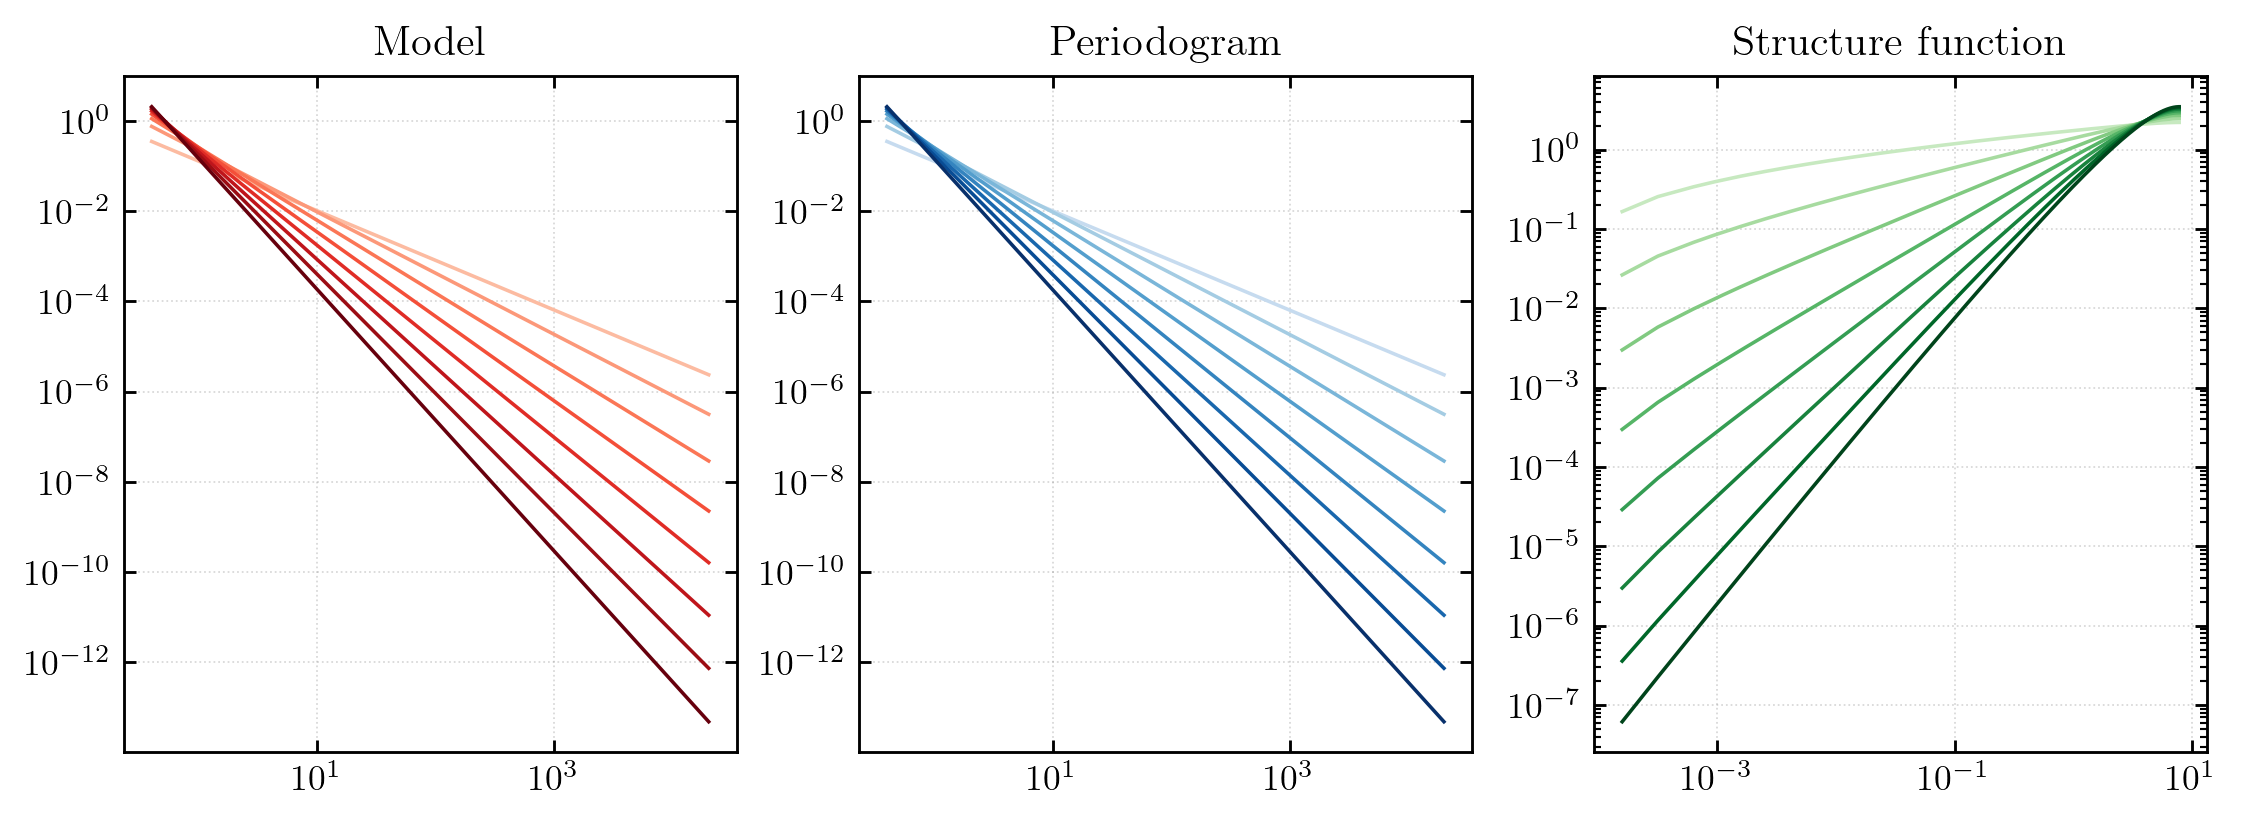

In [2]:
amin, amax = -2.9, -1.1#-(D+2.), -D
NUM = 8
alphas = np.linspace(amax, amin, NUM)

np.random.seed(1234)
fields = []

for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), gfunc='pure_pow'))

models = []
Pspecs = []
Ssf = []
Sacf = []
all_acf = []
all_sf = []
for i, f in enumerate(fields):
    print(i)
    kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    fekD = fekD * (dk/twopi)**D
    _km, _fekm, _ = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims,
        ignore_nan=True, nan_small=True, max_bin=np.pi*N/L, min_bin=dk)
        #kwargs={'ignore_nan': True, 'nan_small': True, 'max_bin': np.pi*N/L, 'min_bin': dk})
    Pspecs.append((_km, _fekm))

    kmesh = spectra_base.wavenumber_mesh(kD)
    fekD_model = funcs.pure_pow(kmesh, (alphas[i],))
    var = np.nansum(fekD_model * (dk/twopi)**D)
    fekD_model = fekD_model / var
    fekD_model = fekD_model * (dk/twopi)**D
    k_model, fek_model, _ = spectra_base.spectrum_integrate(kD, fekD_model, spec_type='omni', lenn=phys_dims,
        ignore_nan=True, nan_small=True, max_bin=np.pi*N/L, min_bin=dk)
    models.append((k_model, fek_model))

    # lv = statfunc_base.get_all_lagvecs([2*n for n in grid_dims])
    # acf = corr.process_lags(f, f, lv, lenn=grid_dims, shape=[2*n for n in grid_dims], periodic=True)
    # all_acf.append(acf)
    # lvm = statfunc_base.get_lagvec_magnitude_array([2*n for n in grid_dims]) * dx
    # l, aacf, w = statistics_base.bin_data(
    #     lvm, acf, bin_func=np.nanmean, cut_excess=True, nan_small=True, ignore_nan=True,
    #     min_bin=0., bin_loc='true_center', max_bin=L/2)
    # Sacf.append((l, aacf))

    lv = statfunc_base.get_all_lagvecs([2*n for n in grid_dims])
    sf = strfn.process_lags(f, f, lv, lenn=grid_dims, shape=[2*n for n in grid_dims], orders=[2], periodic=True)[0]
    lvm = statfunc_base.get_lagvec_magnitude_array([2*n for n in grid_dims]) * dx
    l, sf2, w = statistics_base.bin_data(
        lvm, sf, bin_func=np.nanmean, cut_excess=True, nan_small=True, ignore_nan=True,
        min_bin=0., bin_loc='true_center', max_bin=L/2)
    Ssf.append((l, sf2))

cols = plt.get_cmap('Greys')(np.linspace(0.25, 1., NUM))
cols1 = plt.cm.Reds(np.linspace(0.25, 1., NUM))
cols2 = plt.cm.Blues(np.linspace(0.25, 1., NUM))
cols3 = plt.cm.Greens(np.linspace(0.25, 1., NUM))

fig, ax = plt.subplots(1, 3, figsize=(3.5*3., 3.5), dpi=256)

for i, a in enumerate(alphas):
    ax[0].plot(models[i][0], models[i][1], linewidth=1., color=cols1[i])
    ax[1].plot(Pspecs[i][0], Pspecs[i][1], linewidth=1., color=cols2[i])
    ax[2].plot(Ssf[i][0], Ssf[i][1], linewidth=1., color=cols3[i])

for axx in ax:
    axx.set_xscale('log')
    axx.set_yscale('log')
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0].set_title('Model')
ax[1].set_title('Periodogram')
ax[2].set_title('Structure function')


In [3]:

import sympy as sp

#sp_H = sp.symbols('H', positive=True, real=True)
sp_alpha = sp.symbols('alpha', positive=True, real=True)#sp.S(1) + sp.S(2)*sp_H

b_bias = sp.S(2)**(sp_alpha/(sp_alpha - sp.S(1))) * (sp.gamma(sp_alpha/sp.S(2) + sp.S(1))/(sp.sqrt(sp.pi)*sp_alpha))**(sp.S(1)/(sp_alpha - sp.S(1)))*sp.gamma(sp.Rational(3,2) - sp_alpha/sp.S(2))**(-sp.S(1)/(sp_alpha - sp.S(1)))
display(b_bias)

spec_bias = sp.S(2)*sp.S(2)**(-sp_alpha) * sp.sqrt(sp.pi) * (sp.gamma((sp.S(3) - sp_alpha) / sp.S(2))/sp.gamma(sp_alpha/sp.S(2)))
display(spec_bias)


2**(alpha/(alpha - 1))*(gamma(alpha/2 + 1)/(sqrt(pi)*alpha))**(1/(alpha - 1))/gamma(3/2 - alpha/2)**(1/(alpha - 1))

2*sqrt(pi)*gamma(3/2 - alpha/2)/(2**alpha*gamma(alpha/2))

In [49]:

def omni_spectrum(ell, sf2, a, b):

    dS = np.gradient(sf2)
    dell = np.gradient(ell)

    fek = (ell)**2 * (dS/dell) * (1. / 2.) / a
    kk = b / ell

    return kk[::-1], fek[::-1]

Especs_11 = []
Especs_true = []

for i, a in enumerate(alphas):
    Especs_11.append(omni_spectrum(*Ssf[i], 1., 1.))
    b_true = np.float64(b_bias.subs({sp_alpha: -a}).evalf())
    Especs_true.append(omni_spectrum(*Ssf[i], b_true, b_true))

from scipy.interpolate import interp1d
def interpolate(k_sf, fek_sf, k_interp):
    f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')
    fek_new = f_int(np.log10(k_interp))
    return 10**fek_new


In [23]:
def set_logticks(ax, x_major=False, y_major=True, x_minor=False, y_minor=True, numticks=50):
    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=numticks)
    if x_major:
        ax.xaxis.set_major_locator(locmaj)
    if y_major:
        ax.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,numticks)], numticks=numticks)
    if x_minor:
        ax.xaxis.set_minor_locator(locmin)
    if y_minor:
        ax.yaxis.set_minor_locator(locmin)

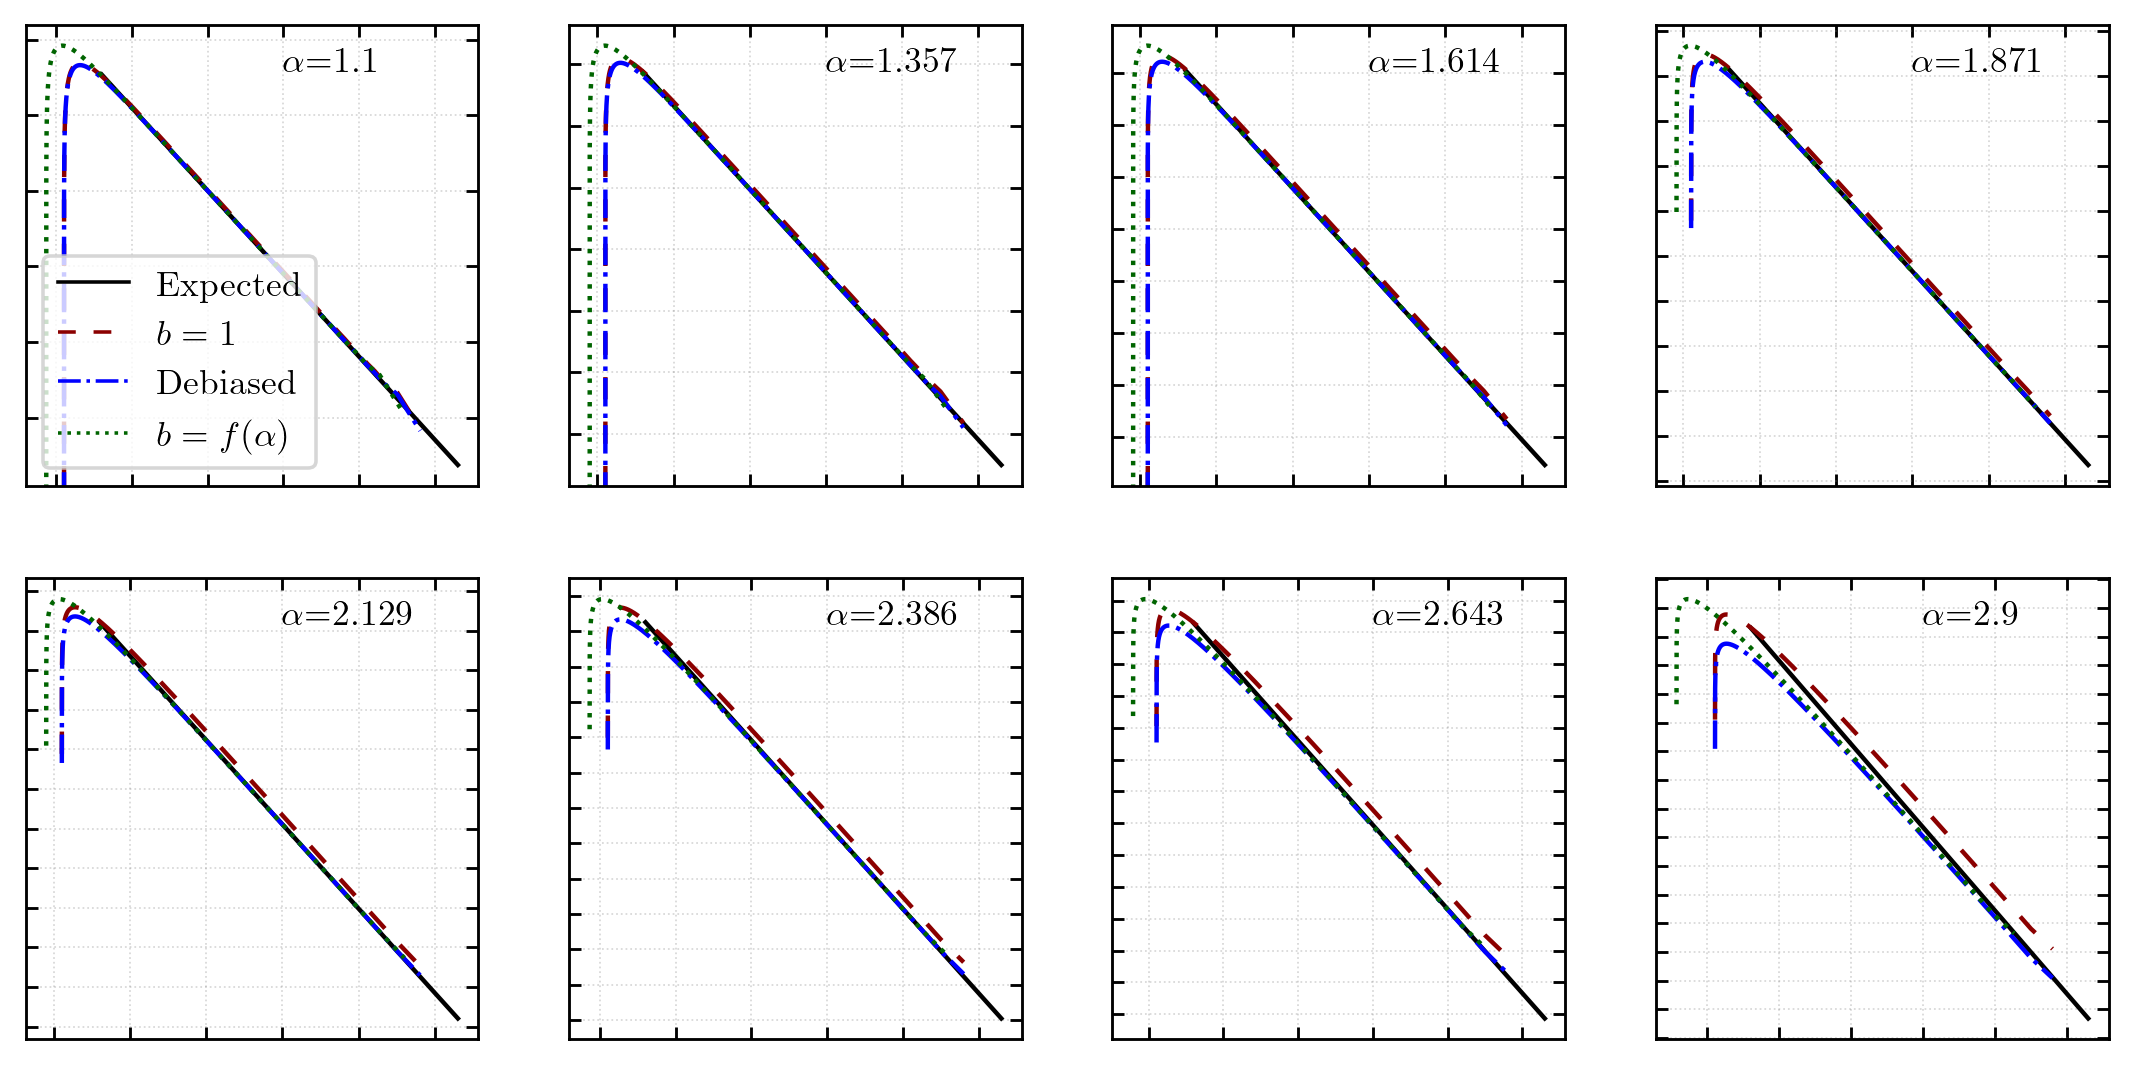

In [27]:

fig, ax = plt.subplots(2, 4, figsize=(3.5*3, 3.5*1.5), dpi=256)

props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)

i = 0
for j in range(2):
    for k in range(4):
        a = alphas[i]

        ax[j][k].plot(Pspecs[i][0], Pspecs[i][1], linewidth=1.25, color='black')
        ax[j][k].plot(Especs_11[i][0], Especs_11[i][1], linewidth=1.25, color='darkred', linestyle=(0,(5,5)))
        ax[j][k].plot(Especs_11[i][0], Especs_11[i][1]/(spec_bias.subs({sp_alpha: -a}).evalf()), linewidth=1.25, color='blue', linestyle='-.')
        ax[j][k].plot(Especs_true[i][0], Especs_true[i][1], linewidth=1.25, color='darkgreen', linestyle=':')

        #ax[j][k].set_title(r'$\alpha=$%s' % -a.round(decimals=3))
        ax[j][k].text(100, 0.9, r'$\alpha$=%s' % -a.round(decimals=3), color='black', transform=ax[j][k].get_xaxis_transform(), bbox=props)

        i = i + 1

for _axx in ax:
    for axx in _axx:
        axx.set_xscale('log')
        axx.set_yscale('log')

        set_logticks(axx, False, True, False, False)

        axx.yaxis.set_ticks_position('both')
        axx.xaxis.set_ticks_position('both')

        axx.tick_params(axis='y', direction='in')
        #axx.tick_params(axis='y', direction='in', which='minor')
        axx.tick_params(axis='x', direction='in')
        axx.tick_params(axis='x', direction='in', which='minor')

        set_logticks(axx, True, False, False, False, 50)

        axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

        axx.set_yticklabels([])
        axx.set_xticklabels([])

ax[0][0].plot([], [], linewidth=1., color='black', label=r'Expected')
ax[0][0].plot([], [], linewidth=1., color='darkred', linestyle=(0,(5,5)), label=r'$b=1$')
ax[0][0].plot([], [], linewidth=1., color='blue', linestyle='-.', label=r'Debiased')
ax[0][0].plot([], [], linewidth=1., color='darkgreen', linestyle=':', label=r'$b = f(\alpha)$')

ax[0][0].legend()

# ax[1].set_ylim((1e-2, 1e5))
#fig.savefig('plots/equiv_sf_comparison_separate.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
#fig.savefig('plots/equiv_sf_comparison_separate.png', transparent=True, bbox_inches='tight', pad_inches=0)


/tmp/ipykernel_19580/3248632256.py:13: RuntimeWarning: invalid value encountered in log
  val1 = np.gradient(np.log(Especs_11[i][1]), np.log(Especs_11[i][0]))
/tmp/ipykernel_19580/3248632256.py:15: RuntimeWarning: invalid value encountered in log
  val2 = np.gradient(np.log(Especs_true[i][1]), np.log(Especs_true[i][0]))


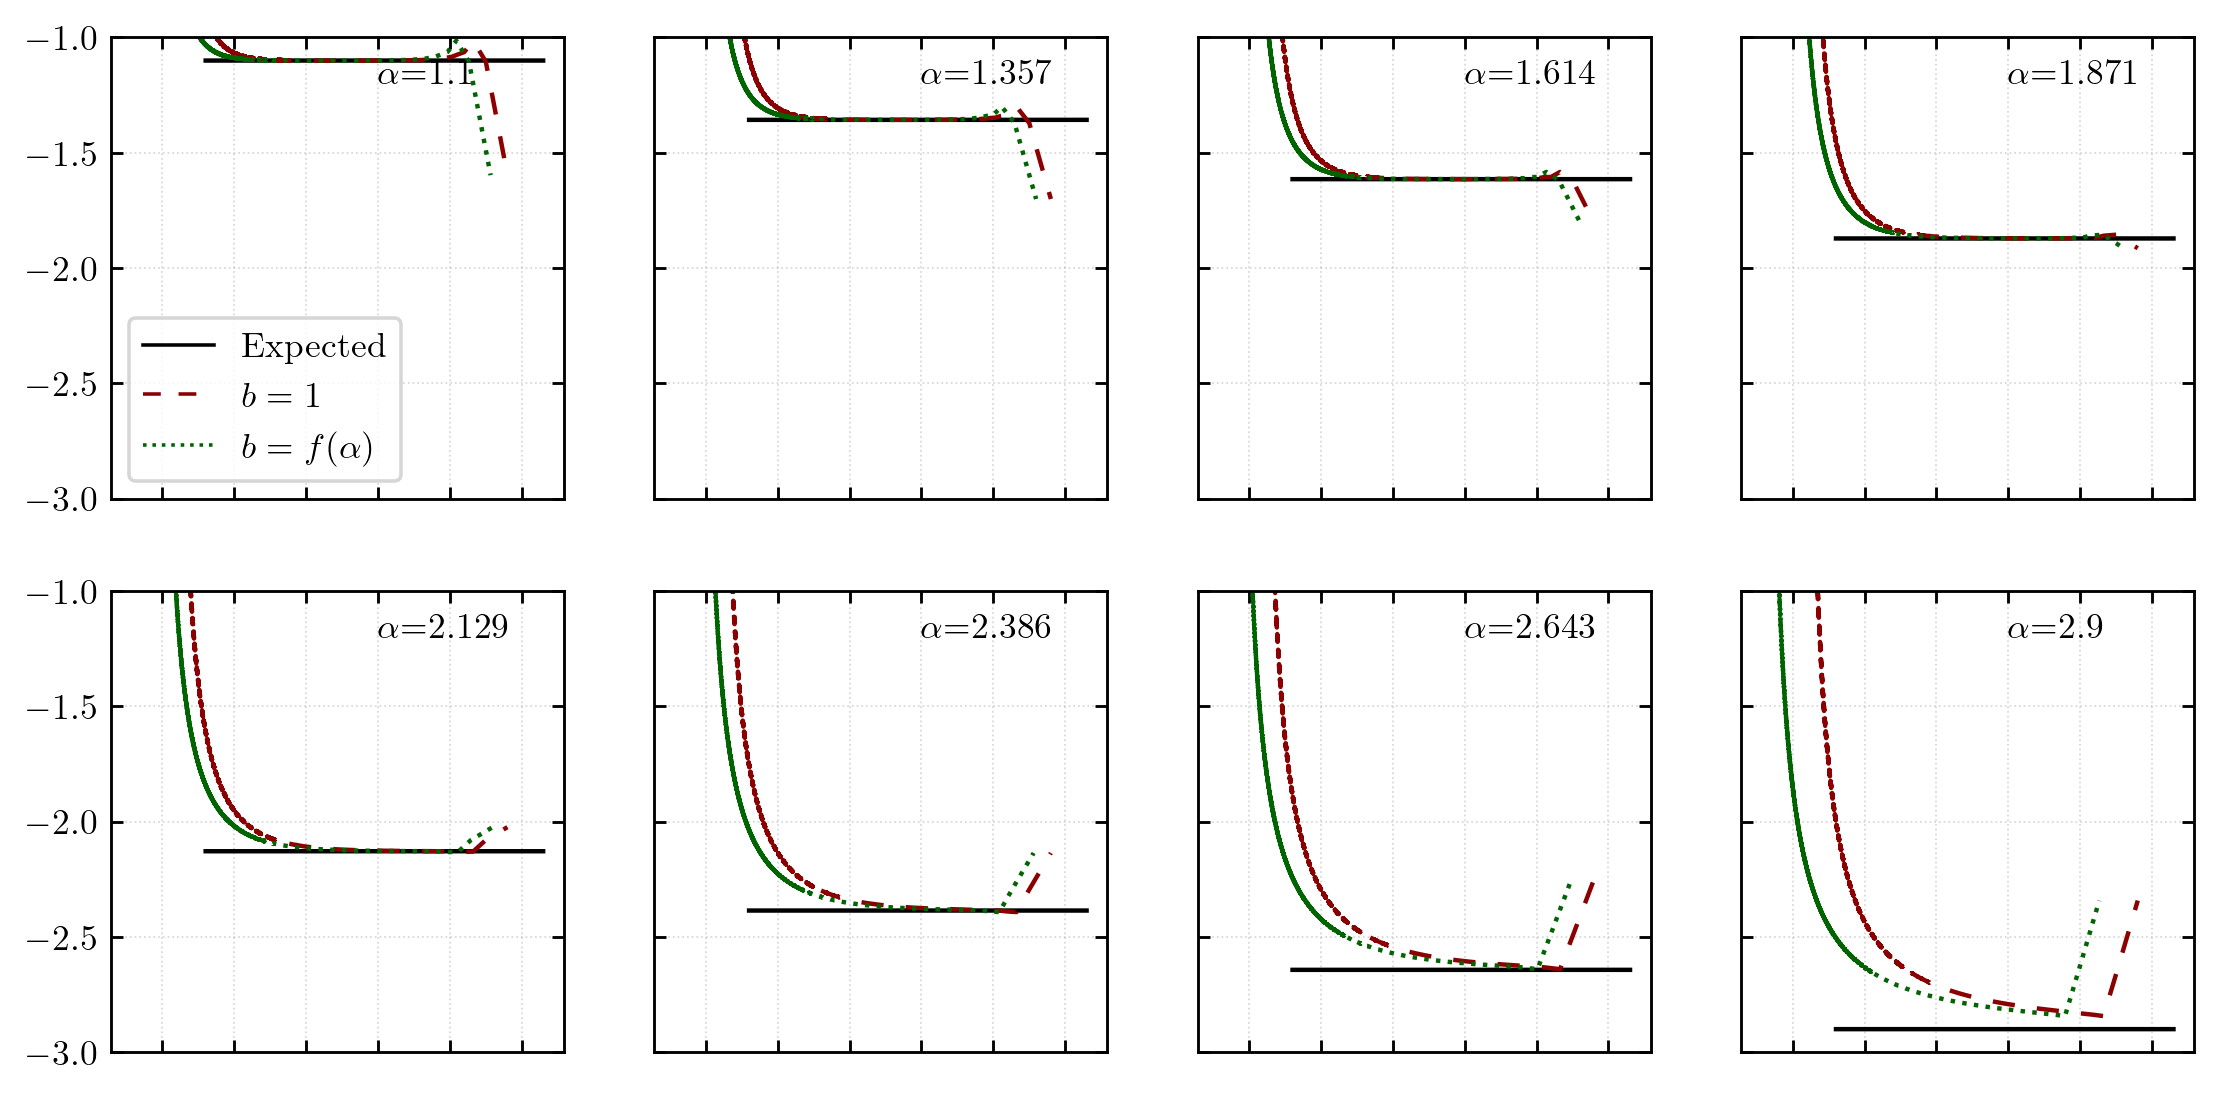

In [57]:

## ESTIMATED POWERLAWS

fig, ax = plt.subplots(2, 4, figsize=(3.5*3, 3.5*1.5), dpi=256, sharex=True, sharey=True)

props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)

i = 0
for j in range(2):
    for k in range(4):
        a = alphas[i]

        val0 = np.gradient(np.log(Pspecs[i][1]), np.log(Pspecs[i][0]))
        val1 = np.gradient(np.log(Especs_11[i][1]), np.log(Especs_11[i][0]))
        #val1 = Especs_11[i][0]/Especs_11[i][1] * np.gradient(Especs_11[i][1], Especs_11[i][0])
        val2 = np.gradient(np.log(Especs_true[i][1]), np.log(Especs_true[i][0]))
        #val2 = Especs_true[i][0]/Especs_true[i][1] * np.gradient(Especs_true[i][1], Especs_true[i][0])

        ax[j][k].plot(Pspecs[i][0], val0, linewidth=1.25, color='black')
        ax[j][k].plot(Especs_11[i][0], val1, linewidth=1.25, color='darkred', linestyle=(0,(5,5)))
        ax[j][k].plot(Especs_true[i][0], val2, linewidth=1.25, color='darkgreen', linestyle=':')

        #ax[j][k].set_title(r'$\alpha=$%s' % -a.round(decimals=3))
        ax[j][k].text(100, 0.9, r'$\alpha$=%s' % -a.round(decimals=3), color='black', transform=ax[j][k].get_xaxis_transform(), bbox=props)

        i = i + 1

for _axx in ax:
    for axx in _axx:
        axx.set_xscale('log')
        #axx.set_yscale('log')

        #set_logticks(axx, False, True, False, False)

        axx.yaxis.set_ticks_position('both')
        axx.xaxis.set_ticks_position('both')

        axx.tick_params(axis='y', direction='in')
        #axx.tick_params(axis='y', direction='in', which='minor')
        axx.tick_params(axis='x', direction='in')
        axx.tick_params(axis='x', direction='in', which='minor')

        set_logticks(axx, True, False, False, False, 50)

        axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

        #axx.set_yticklabels([])
        axx.set_xticklabels([])

        axx.set_ylim((-3., -1.))

ax[0][0].plot([], [], linewidth=1., color='black', label=r'Expected')
ax[0][0].plot([], [], linewidth=1., color='darkred', linestyle=(0,(5,5)), label=r'$b=1$')
#ax[0][0].plot([], [], linewidth=1., color='blue', linestyle='-.', label=r'Debiased')
ax[0][0].plot([], [], linewidth=1., color='darkgreen', linestyle=':', label=r'$b = f(\alpha)$')

ax[0][0].legend()

# ax[1].set_ylim((1e-2, 1e5))
fig.savefig('plots/powerlaw_fbm_powerlaw.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/powerlaw_fbm_powerlaw.png', transparent=True, bbox_inches='tight', pad_inches=0)


In [55]:

Especs_bias = []

for i, a in enumerate(alphas):
    
    powerlaw = np.gradient(np.log(Especs_11[i][1]), np.log(Especs_11[i][0]))

    powerlaw[powerlaw > -1.1] = -1.1
    powerlaw[powerlaw < -2.9] = -2.9

    inst_bias = []
    for pl in powerlaw:
        inst_bias.append(np.float64(spec_bias.subs({sp_alpha: -pl}).evalf()))
    inst_bias = np.array(inst_bias)

    Especs_bias.append(inst_bias)


/tmp/ipykernel_19580/613476930.py:5: RuntimeWarning: invalid value encountered in log
  powerlaw = np.gradient(np.log(Especs_11[i][1]), np.log(Especs_11[i][0]))


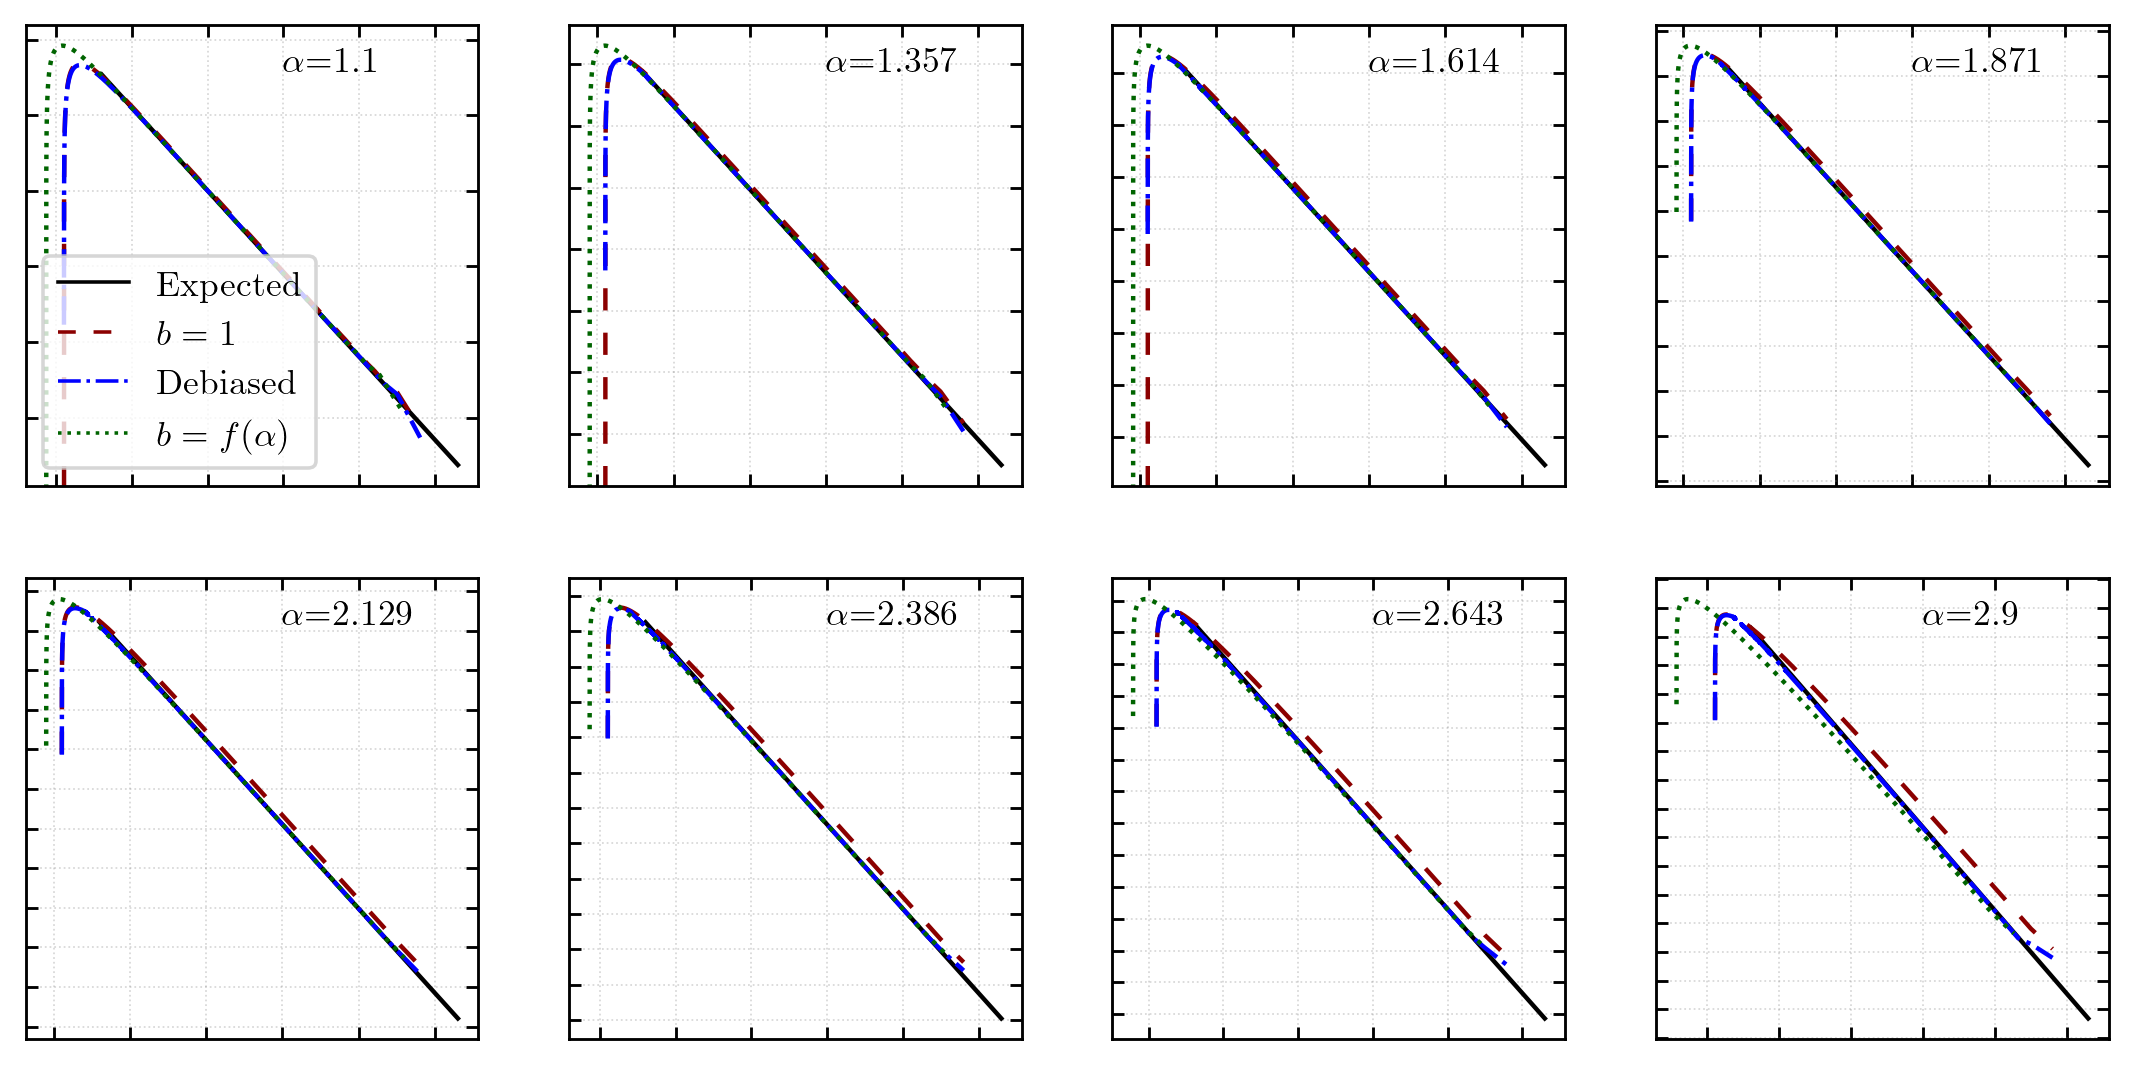

In [58]:

## Now try to practically debias

fig, ax = plt.subplots(2, 4, figsize=(3.5*3, 3.5*1.5), dpi=256)

props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)

i = 0
for j in range(2):
    for k in range(4):
        a = alphas[i]

        ax[j][k].plot(Pspecs[i][0], Pspecs[i][1], linewidth=1.25, color='black')
        ax[j][k].plot(Especs_11[i][0], Especs_11[i][1], linewidth=1.25, color='darkred', linestyle=(0,(5,5)))

        ax[j][k].plot(Especs_11[i][0], Especs_11[i][1]/Especs_bias[i], linewidth=1.25, color='blue', linestyle='-.')

        ax[j][k].plot(Especs_true[i][0], Especs_true[i][1], linewidth=1.25, color='darkgreen', linestyle=':')

        #ax[j][k].set_title(r'$\alpha=$%s' % -a.round(decimals=3))
        ax[j][k].text(100, 0.9, r'$\alpha$=%s' % -a.round(decimals=3), color='black', transform=ax[j][k].get_xaxis_transform(), bbox=props)

        i = i + 1

for _axx in ax:
    for axx in _axx:
        axx.set_xscale('log')
        axx.set_yscale('log')

        set_logticks(axx, False, True, False, False)

        axx.yaxis.set_ticks_position('both')
        axx.xaxis.set_ticks_position('both')

        axx.tick_params(axis='y', direction='in')
        #axx.tick_params(axis='y', direction='in', which='minor')
        axx.tick_params(axis='x', direction='in')
        axx.tick_params(axis='x', direction='in', which='minor')

        set_logticks(axx, True, False, False, False, 50)

        axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

        axx.set_yticklabels([])
        axx.set_xticklabels([])

ax[0][0].plot([], [], linewidth=1., color='black', label=r'Expected')
ax[0][0].plot([], [], linewidth=1., color='darkred', linestyle=(0,(5,5)), label=r'$b=1$')
ax[0][0].plot([], [], linewidth=1., color='blue', linestyle='-.', label=r'Debiased')
ax[0][0].plot([], [], linewidth=1., color='darkgreen', linestyle=':', label=r'$b = f(\alpha)$')

ax[0][0].legend()

# ax[1].set_ylim((1e-2, 1e5))
fig.savefig('plots/powerlaw_fbm_practical_debias.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/powerlaw_fbm_practical_debias.png', transparent=True, bbox_inches='tight', pad_inches=0)
